# Integrate an ArcGIS Feature Service

This notebook integrates a public ArcGIS Feature Service into ARGUS using the new `%%skill-build` cell magic. The user writes no Python — paste the
service URL into a `%%skill-build` cell and ARGUS produces a queryable skill in the same cell.

We integrate the California wildfire perimeters service (CAL FIRE / NIFC / FIRIS), then query it in natural language to confirm it works end-to-end. A
follow-up query joins the new skill against a public-schools skill from GitHub, confirming the freshly-built skill behaves like any other skill in the
agent's toolset.

In [ ]:
%reset

In [2]:
%%skill-build
https://services1.arcgis.com/jUJYIo9tSA7EHvfZ/arcgis/rest/services/CA_Perimeters_NIFC_FIRIS_public_view/FeatureServer/0

I'll start by reading the `arcgis-feature-skill-builder` meta-skill instructions, since this URL contains `/FeatureServer/0`.

This is the right meta-skill for the URL. Let me set up a task list and start by fetching the service metadata.

`SAGE_OUTPUT_DIR` isn't set in this context, so I'll use the specified working directory directly.

Metadata retrieved. The service is "FIRIS WFIGS ComboLayer" with polygon geometry, SR wkid 4269 (NAD83), 14 fields, no domains. The meta-skill's own example suggests `ca-wildfire-perimeters` as the name for this exact service. Now I'll probe candidate categorical fields in a single batched pass.

Now I'll write and run the canonical probe script. Applying the skip-rules: `OBJECTID` and `GlobalID` are ID fields; `description`, `incident_name`, `incident_number` are free-text/ID-like; all date fields skip by pattern. That leaves `type`, `source`, `mission`, and `displayStatus` as the candidates to probe.

...

Now I'll write the complete SKILL.md with all sections — frontmatter, field table, code dictionaries, the verbatim loader, and worked examples using real codes.

Now let me verify the file against the Quality Checklist by checking it parses and the loader runs a real query.

All quality checks pass. Let me do a final functional verification that the embedded loader actually returns data from the live service.

The loader works correctly against the live service — returns real data (17 active fires, 58 FIRIS perimeters in SoCal) in EPSG:4326. The build is a clean one-shot (probe succeeded first try; the only edit was a retry of a transient 504 on a single field, which is a network issue not a code bug, so no Learnings.md update is needed).

✓ Built skill **`ca-wildfire-perimeters`** at `_skills_/ca-wildfire-perimeters/SKILL.md` (14 fields, 3 categorical dictionaries, 5 worked examples; loader verified live — returns 17 active fires and 58 FIRIS perimeters correctly).

Each row is a California wildfire. Try queries like:
- "show me all active California wildfires"
- "find California wildfires larger than 10,000 acres"
- "list FIRIS-sourced wildfires in Southern California"

The skill is available in the next `%%ask` cell.

I'll read the wildfire perimeters skill to find the correct query pattern for acreage filtering.

This skill is in the Learnings list, so I'll read its Learnings.md to apply any pre-emptive fixes.

Now I'll write the query script using the skill's `get_features` pattern, filtering for fires over 1000 acres.

All 38 fires are Inactive, so the colormap maps to a single color. I'll create a bar chart of the largest fires using the palette color.

**38 California wildfires larger than 1,000 acres** , totaling **135,618 acres** . All are currently marked Inactive.


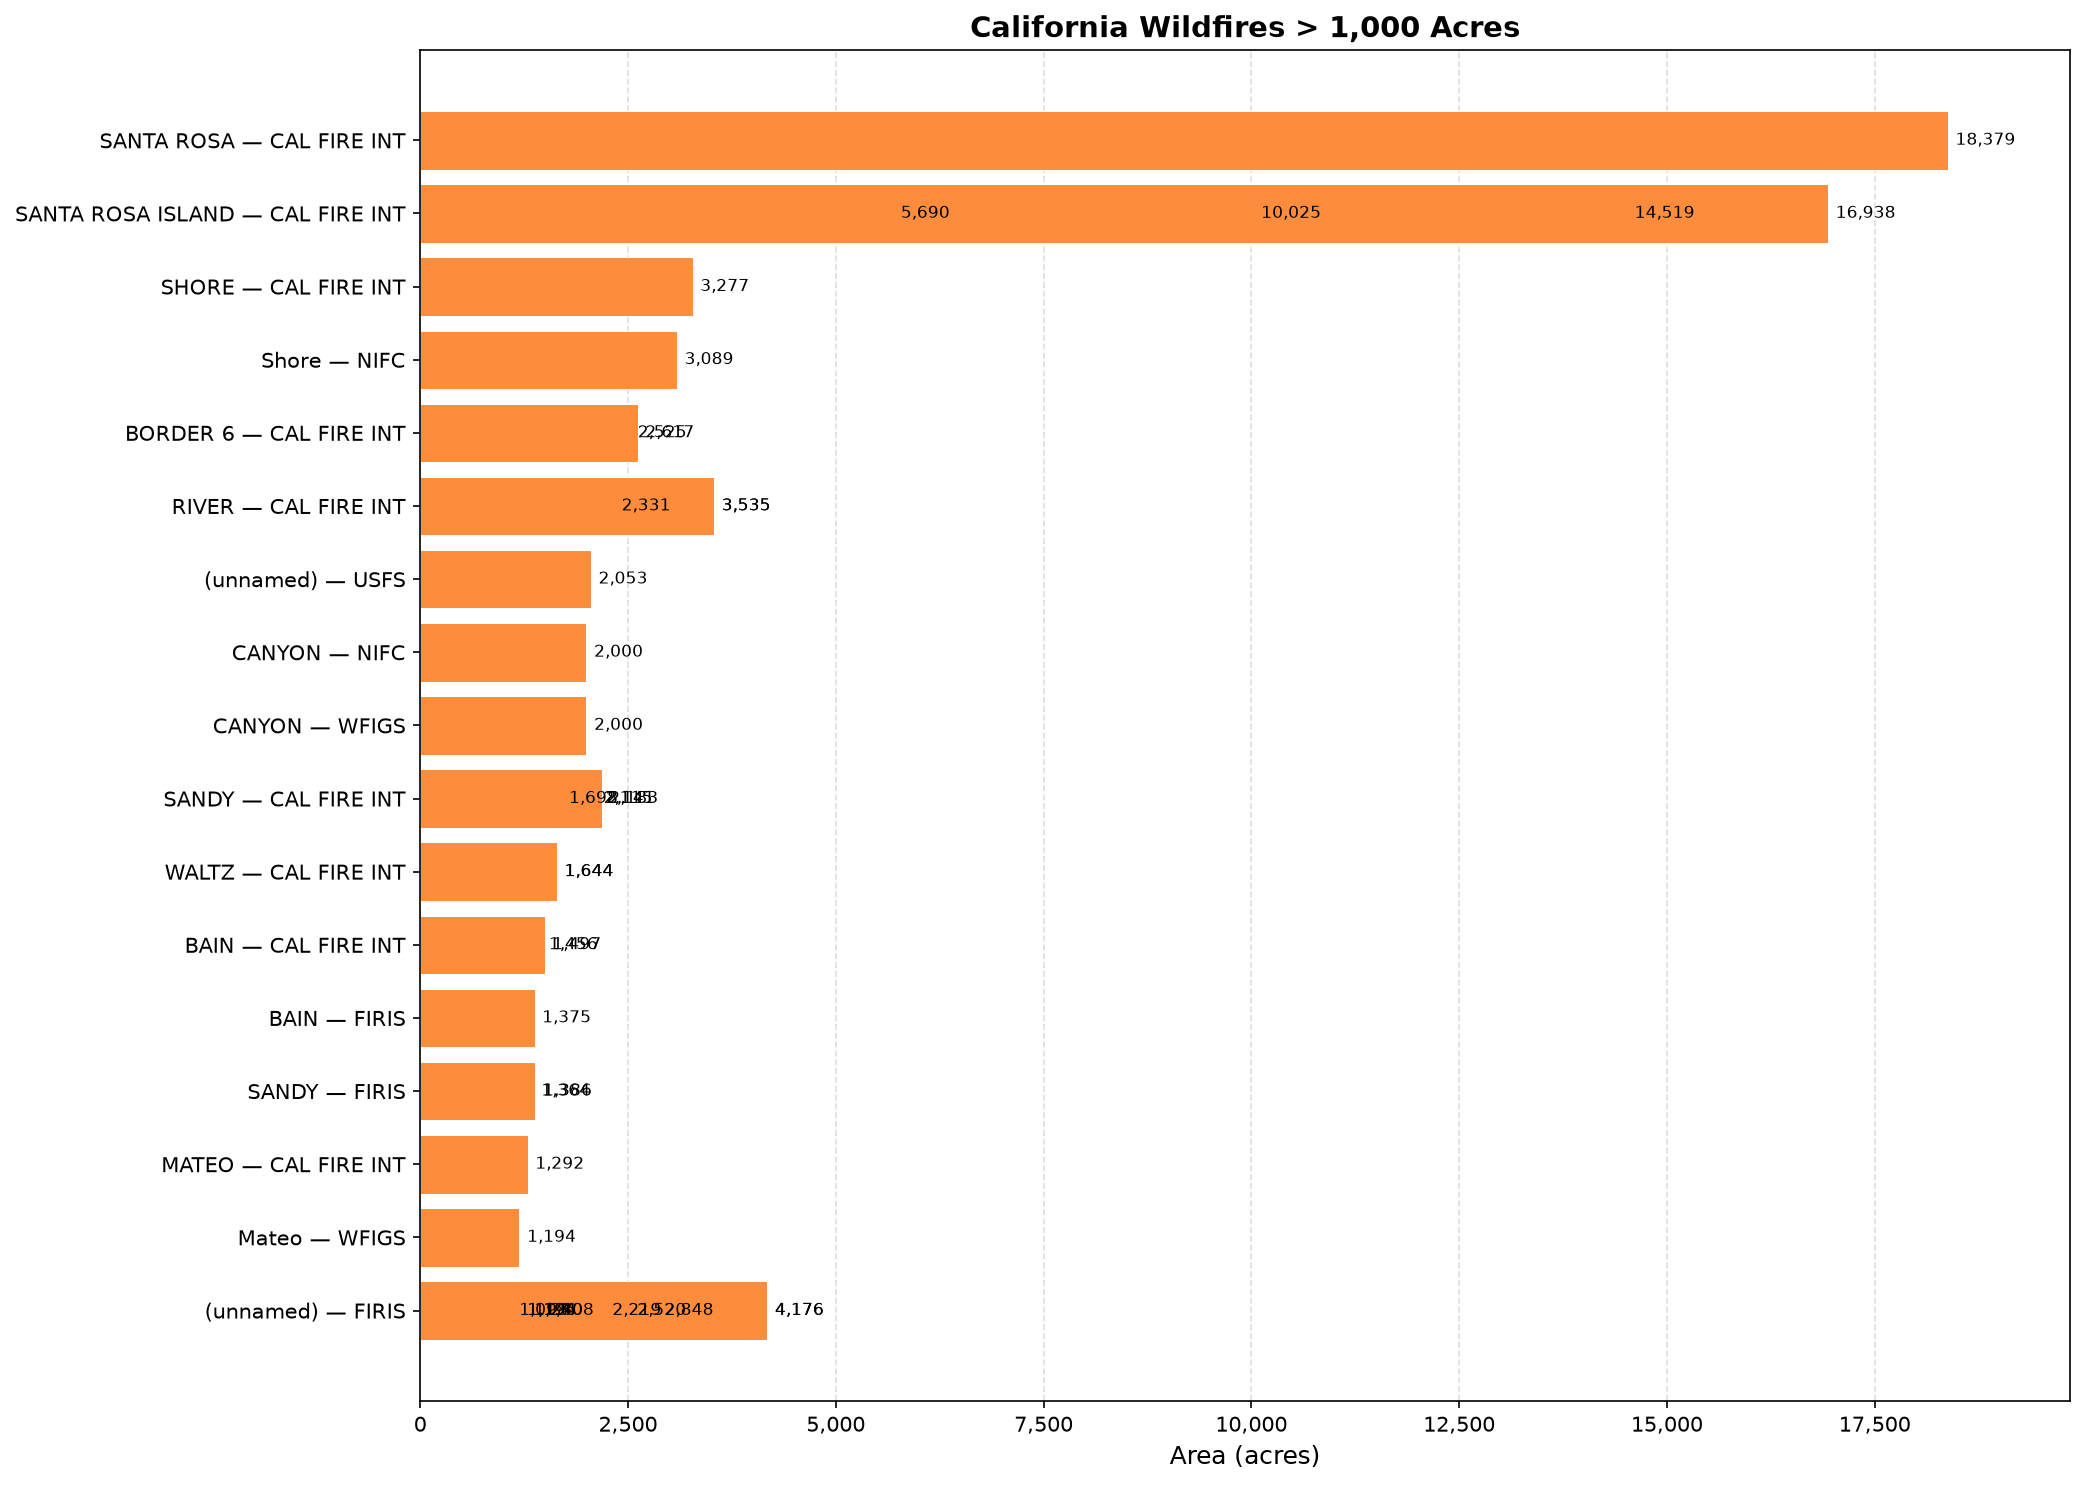

**Top 10 largest fires:**

| Rank | Incident | Source | Acreage |
|---|---|---|---|
| 1 | SANTA ROSA | CAL FIRE INTEL FLIGHT DATA | 18,379 |
| 2 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 16,938 |
| 3 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 14,519 |
| 4 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 10,025 |
| 5 | SANTA ROSA ISLAND | CAL FIRE INTEL FLIGHT DATA | 5,690 |
| 6 | (unnamed) | FIRIS | 4,176 |
| 7 | (unnamed) | FIRIS | 4,176 |
| 8 | RIVER | CAL FIRE INTEL FLIGHT DATA | 3,535 |
| 9 | RIVER | CAL FIRE INTEL FLIGHT DATA | 3,535 |
| 10 | SHORE | CAL FIRE INTEL FLIGHT DATA | 3,277 |

**By source:**

| Source | Count | Share |
|---|---|---|
| CAL FIRE INTEL FLIGHT DATA | 20 | 53% |
| FIRIS | 13 | 34% |
| NIFC | 2 | 5% |
| WFIGS | 2 | 5% |
| USFS | 1 | 3% |

A few notes: 8 of the 38 fires have no incident name recorded (all FIRIS-sourced); some incidents appear under multiple perimeters — for example, "SANTA ROSA ISLAND" accounts for 4 separate perimeter records (likely repeat mappings of the same fire), and "RIVER" / "SANDY" / "BAIN" each have multiple entries. The five SANTA ROSA records alone account for ~65,500 acres of the total.

In [3]:
%%ask
Find all California wildfires > 1000 acres

In [4]:
%%skill
https://github.com/klinucsd/sage_skills/tree/main/society/public-schools

I'll find schools within one mile of large wildfires. Let me consult the relevant skills first.

This is a multi-step spatial analysis. Let me set up a plan.

Let me check the existing colormap and fire data structure to reuse established schemes.

Fires use the red/orange family. I'll use blue for schools to keep layers visually distinct. Writing the spatial analysis script.

Analysis succeeded — 17 schools within 1 mile. Let me fix the colormap to cover the "NOT REPORTED" level that appeared in the data, then finalize.

I removed the "OTHER" fallback key but the chart code still references it. Fixing that.

Run completed successfully. Let me record the lesson learned (this was an edit-and-retry cycle), then verify the nearest-fire name attribution for those NaN entries.

The edit-and-retry here was a trivial Python dict-key bug (unrelated to skill domain), so no Learnings.md entry is warranted. Let me verify the full results by reading the output GeoJSON.

All 17 schools verified — data is clean. The `null` nearest_fire values correspond to the unnamed FIRIS fires (which have no `incident_name`). Updating the plan and writing the final report.

**17 public schools** sit within one mile of a California wildfire larger than 1,000 acres. All associated fires are currently Inactive.


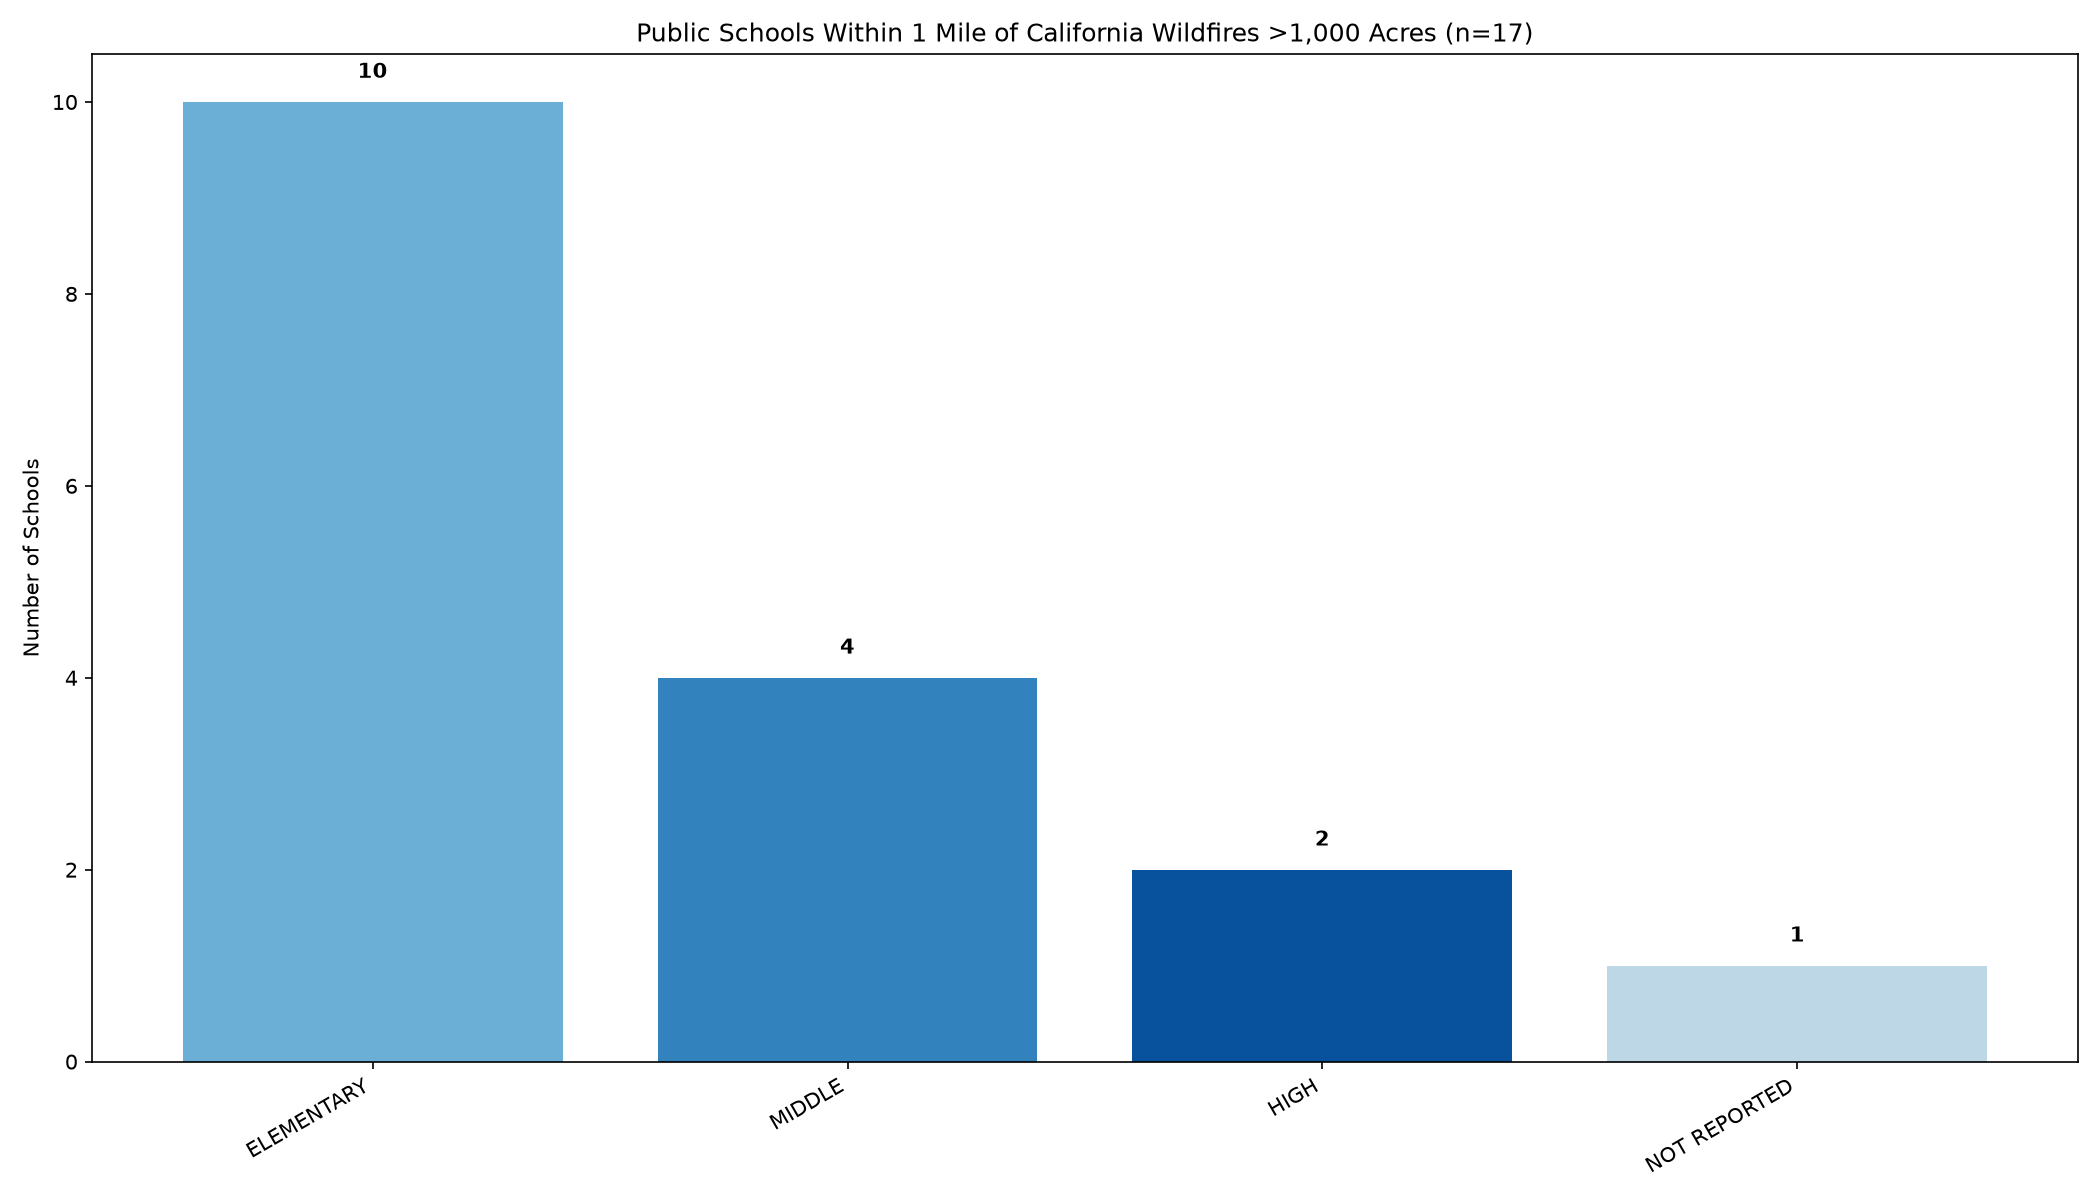

**Method:** Loaded the 38 fires >1,000 acres from the prior cell, buffered each perimeter by exactly 1 mile (1,609 m) in California Albers (EPSG:3310) for accurate distance, then fetched all 5,883 CA public schools in the buffered region and selected those falling inside the buffered perimeter area.

**Schools by level:**

| Level | Count |
|---|---|
| Elementary | 10 |
| Middle | 4 |
| High | 2 |
| Not Reported | 1 |

**Geographic concentration:** All 17 schools cluster in two areas of Southern California:
- **Moreno Valley / Riverside area (Riverside County)** — 13 schools, nearest to a ~4,176-acre FIRIS fire (unnamed) and the ~1,497-acre BAIN fire
- **Simi Valley area (Ventura County)** — 4 schools, nearest to the ~2,183-acre SANDY fire

**Closest schools to a fire perimeter (top 10):**

| School | City | Level | Nearest Fire | Fire Acres | Distance |
|---|---|---|---|---|---|
| RANCHO VERDE HIGH | Moreno Valley | High | (unnamed FIRIS) | 4,176 | 0.29 mi |
| CRESTVIEW ELEMENTARY | Simi Valley | Elementary | SANDY | 2,183 | 0.30 mi |
| RIDGE CREST ELEMENTARY | Moreno Valley | Elementary | (unnamed FIRIS) | 4,176 | 0.37 mi |
| HILLSIDE MIDDLE | Simi Valley | Middle | SANDY | 2,183 | 0.43 mi |
| MOUNTAIN VIEW ELEMENTARY | Simi Valley | Elementary | SANDY | 2,183 | 0.50 mi |
| ROSEMARY KENNEDY ELEMENTARY | Riverside | Elementary | BAIN | 1,497 | 0.53 mi |
| LOMA VISTA MIDDLE | Moreno Valley | Middle | BAIN | 1,375 | 0.53 mi |
| INDIAN HILLS ELEMENTARY | Jurupa Valley | Elementary | BAIN | 1,497 | 0.54 mi |
| HOLLOW HILLS ELEMENTARY | Simi Valley | Elementary | SANDY | 2,183 | 0.54 mi |
| LANDMARK MIDDLE | Moreno Valley | Middle | (unnamed FIRIS) | 4,176 | 0.55 mi |

**Total enrollment at risk** (15 of 17 reporting): **~13,400 students** , with NORTE VISTA HIGH (2,144) and RANCHO VERDE HIGH (2,371) the two largest.

In [5]:
%%ask
Show public schools within one mile from a wildfire larger than 1,000 acres